In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
print("1. Memuat dan Membersihkan Data...")

dataset_path = 'dataset.csv'
df = pd.read_csv(dataset_path)

df['Harga'] = df['Harga'].str.replace('Rp', '', regex=False).str.replace(',', '', regex=False)
df['Harga'] = df['Harga'].str.strip().replace('-', np.nan)
df['Harga'] = df['Harga'].replace('', np.nan)

df_clean = df.dropna()

df_clean['Harga'] = df_clean['Harga'].astype(int)

X = df_clean.drop(columns=[df_clean.columns[-1]]) 
y = df_clean[df_clean.columns[-1]]

X = pd.get_dummies(X, drop_first=True)
print(f"Total data bersih: {X.shape[0]} baris, {X.shape[1]} fitur.")

1. Memuat dan Membersihkan Data...


C:\Users\ASUS\AppData\Local\Temp\ipykernel_55256\3653390061.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Harga'] = df_clean['Harga'].astype(int)


Total data bersih: 36068 baris, 120 fitur.


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data latih (80%) dan uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

Dimensi fitur sebelum PCA : 120 kolom
Dimensi fitur setelah PCA : 109 kolom (Mempertahankan 95% informasi)


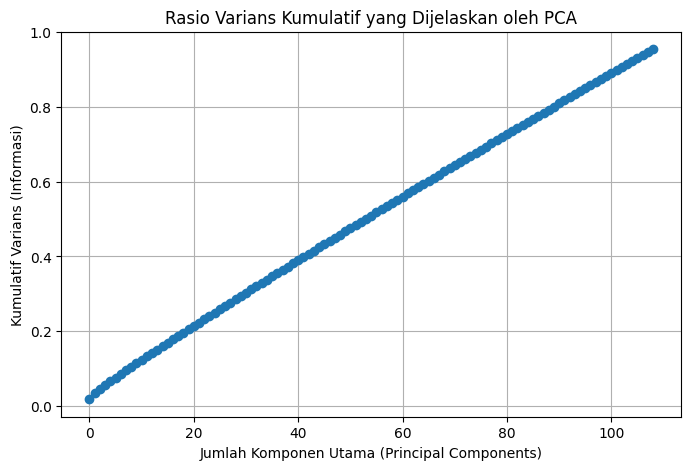

In [4]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Dimensi fitur sebelum PCA : {X_train.shape[1]} kolom")
print(f"Dimensi fitur setelah PCA : {X_train_pca.shape[1]} kolom (Mempertahankan 95% informasi)")

# Visualisasi Kumulatif Varians PCA
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('Rasio Varians Kumulatif yang Dijelaskan oleh PCA')
plt.xlabel('Jumlah Komponen Utama (Principal Components)')
plt.ylabel('Kumulatif Varians (Informasi)')
plt.grid(True)
plt.show()

In [5]:
best_rf = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42)
best_rf.fit(X_train_pca, y_train)

RandomForestRegressor(max_depth=20, random_state=42)

Root Mean Squared Error (RMSE) : Rp 9,822.01
Mean Absolute Error (MAE)      : Rp 4,397.82
Skor R-Squared (R2)            : 90.69%


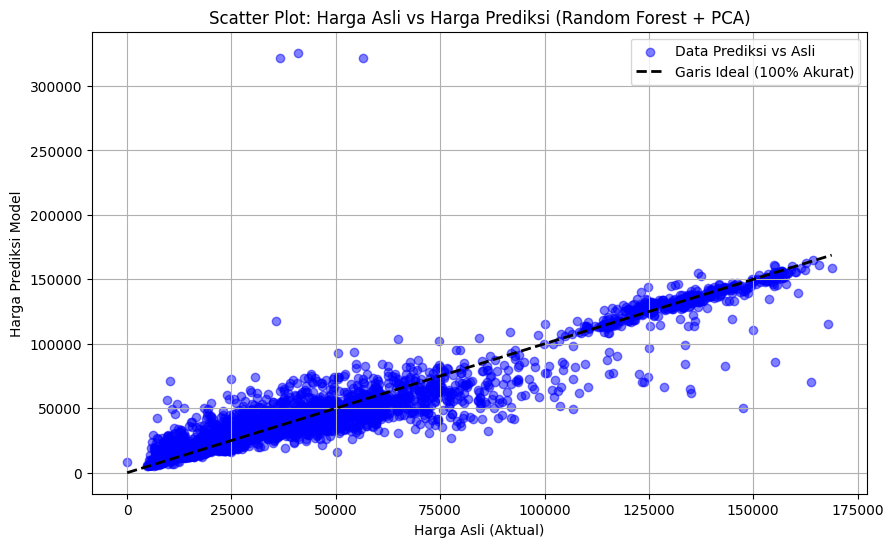

In [6]:
y_pred = best_rf.predict(X_test_pca)

# Metrik Evaluasi Regresi
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE) : Rp {rmse:,.2f}")
print(f"Mean Absolute Error (MAE)      : Rp {mae:,.2f}")
print(f"Skor R-Squared (R2)            : {r2 * 100:.2f}%")

# Visualisasi: Harga Asli vs Prediksi
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', label='Data Prediksi vs Asli')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Garis Ideal (100% Akurat)')
plt.title('Scatter Plot: Harga Asli vs Harga Prediksi (Random Forest + PCA)')
plt.xlabel('Harga Asli (Aktual)')
plt.ylabel('Harga Prediksi Model')
plt.legend()
plt.grid(True)
plt.show()